1. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

import warnings
warnings.filterwarnings('ignore')

2. Create Data Paths

In [26]:
RAW_DATA_PATH = "../data/Data"
PROCESSED_DATA_PATH = "../data/processed"

3. Load All CSV Files Automatically

In [27]:
from glob import glob

csv_files = glob(f"{RAW_DATA_PATH}/*.csv")

csv_files

['../data/Data\\AAPL.csv',
 '../data/Data\\AMZN.csv',
 '../data/Data\\GOOG.csv',
 '../data/Data\\META.csv',
 '../data/Data\\NVDA.csv']

4. Build Reusable Analysis Function

In [33]:
def analyze_stock(filepath):

    stock_name = Path(filepath).stem

    print(f"\nAnalyzing {stock_name}...")

    df = pd.read_csv(filepath)

    print("Columns:", df.columns.tolist())

    # Convert Date
    df['Date'] = pd.to_datetime(df['Date'])

    # Sort values
    df.sort_values('Date', inplace=True)

    # Set index
    df.set_index('Date', inplace=True)

    # Remove missing values
    df.dropna(inplace=True)

    # Numeric columns
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

    df[numeric_cols] = df[numeric_cols].astype(float)

    # =====================
    # Indicators
    # =====================

    # SMA
    df['SMA_20'] = SMAIndicator(
        close=df['Close'],
        window=20
    ).sma_indicator()

    # EMA
    df['EMA_20'] = EMAIndicator(
        close=df['Close'],
        window=20
    ).ema_indicator()

    # RSI
    df['RSI'] = RSIIndicator(
        close=df['Close'],
        window=14
    ).rsi()

    # MACD
    macd = MACD(close=df['Close'])

    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()

    # Daily Returns
    df['Daily_Return'] = df['Close'].pct_change()

    return df

In [36]:
all_data['AAPL'].head()

,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_Signal,Daily_Return
Date,,,,,,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09,NaN,NaN,NaN,NaN,NaN,0.042204
2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09,NaN,NaN,NaN,NaN,NaN,-0.016494
2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08,NaN,NaN,NaN,NaN,NaN,-0.021609
2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08,NaN,NaN,NaN,NaN,NaN,0.018570


5. Run Workflow for All Stocks

In [37]:
all_data = {}

for file in csv_files:

    stock_name = Path(file).stem

    analyzed_df = analyze_stock(file)

    all_data[stock_name] = analyzed_df


Analyzing AAPL...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing AMZN...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing GOOG...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing META...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing NVDA...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


6. Visualize Any Stock

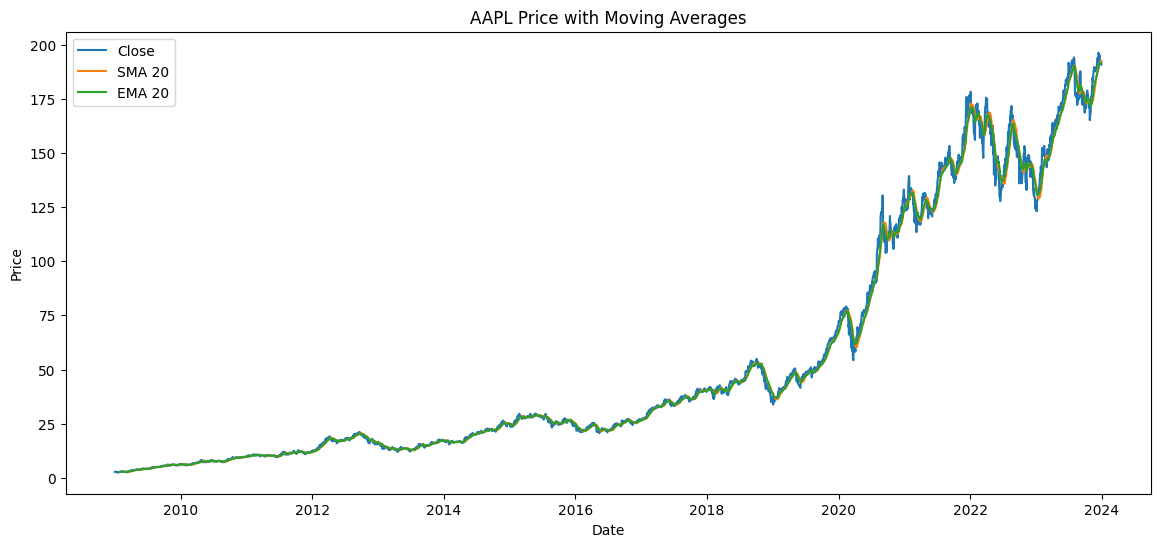

In [38]:
#Example for AAPL
aapl_df = all_data['AAPL']

plt.figure(figsize=(14,6))

plt.plot(aapl_df.index, aapl_df['Close'], label='Close')
plt.plot(aapl_df.index, aapl_df['SMA_20'], label='SMA 20')
plt.plot(aapl_df.index, aapl_df['EMA_20'], label='EMA 20')

plt.title('AAPL Price with Moving Averages')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

7. Create Reusable Visualization Function

In [39]:
def plot_stock_indicators(df, stock_name):
    
    # Price Plot
    plt.figure(figsize=(14,6))
    
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['SMA_20'], label='SMA 20')
    plt.plot(df.index, df['EMA_20'], label='EMA 20')
    
    plt.title(f'{stock_name} Price with Moving Averages')
    
    plt.legend()
    
    plt.show()
    
    # RSI Plot
    plt.figure(figsize=(14,4))
    
    plt.plot(df.index, df['RSI'], label='RSI')
    
    plt.axhline(70, linestyle='--')
    plt.axhline(30, linestyle='--')
    
    plt.title(f'{stock_name} RSI')
    
    plt.legend()
    
    plt.show()
    
    # MACD Plot
    plt.figure(figsize=(14,4))
    
    plt.plot(df.index, df['MACD'], label='MACD')
    plt.plot(df.index, df['MACD_Signal'], label='Signal')
    
    plt.title(f'{stock_name} MACD')
    
    plt.legend()
    
    plt.show()